# Пример

C:\Users\User\AppData\Local\Temp\ipykernel_16600\4155044377.py:10: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include=['object']).describe() # Описательная статистика для категориальных данных


<Axes: >

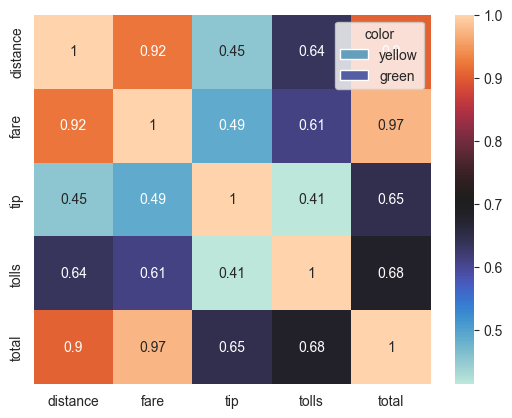

In [1]:
import pandas as pd # Импортируем библиотеку для работы с датасетом
import seaborn as sns # Импортируем библиотеки для работы с визуализацией
import matplotlib.pyplot as plt

sns.set_style("whitegrid") # Устанавливаем тему для графиков
sns.set_palette(sns.color_palette("icefire")) # Устанавливаем единую па-литру для всех визуализаций
df = sns.load_dataset("taxis") # Загружаем датасет о поездках на такси
df.head() # Проверяем загрузку

df.select_dtypes(include=['object']).describe() # Описательная статистика для категориальных данных
# df.select_dtypes() обращается к переменным определенного типа
# Метод .describe() выводит описательную статистику по каждой переменной

df.select_dtypes(include=['float64', 'int64']).describe() # Описательная статистика для числовых данных

df.dtypes # Типы данных датафрейма можно посмотреть при помощи команды .dtypes

# Визуализация данных в разведовательном анализе данных начинается с по-строения распределения при помощи гистограмм
# Гистограмма -  визуальный элемент показывающий, с какой частотой один и тот же параметр принимает определенные значения.
# Рассмотрим построение на примере показателя payment (вид оплаты)
df['payment'].value_counts() # метод .value_counts() выводит частоту для каждого значения переменной

# Построение гистограммы
sns.countplot(df, x='payment')
# По данному графику можем сделать вывод, что кредитными картами пассажиры пользуются в 2 раза чаще

# Также при построении гистограмм можно добавлять различные срезы в данных при помощи атрибута hue = <Переменная> 
sns.countplot(df, x='payment', hue = 'color')
# В данном случае можем сделать вывод, что чаще всего к пассажирам приез-жает желтая машина и при окончании поездки они расплачиваются картой

# Построим гистограмму для числовой переменной total, параметр bins задает число разбиений
sns.histplot(df, x='total', bins = 30)
# По данной диаграмме можем сделать вывод, что распределение ассиметрич-ное, большинство заказов такси стоят до 25$ 
# Длинный хвост у распределения может указывать на наличие выбросов, либо поездку на большое расстояние

# Для исследования взаимосвязей рассмотрим визуализацию тепловой карты (heatmap)
# Данные для построения диаграммы - коэффициенты корреляции между перемен-ными, вычисляется при помощи функции .corr()
# Параметры annot и cmap добавляют подписи и меняют цвет
sns.heatmap(df[['distance','fare','tip','tolls','total']].corr(), annot=True, cmap="icefire")
# По графику заметим, что обратной корреляции в данных не наблюдается
# Красный цвет означает сильную взаимосвязь, голубой - более слабую

<Axes: xlabel='fare', ylabel='distance'>

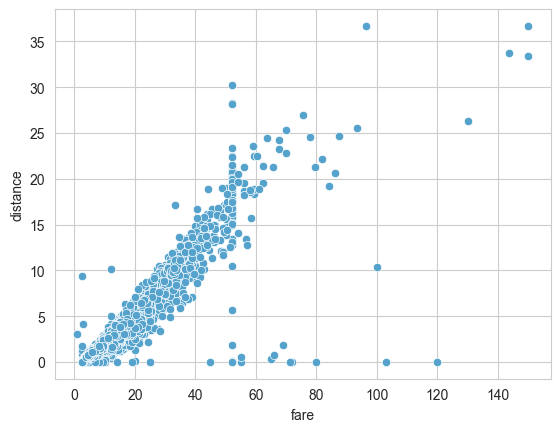

In [2]:
# Рассмотрим более детально взаимосвязь переменных fare (стоимость поезд-ки) и distance (дистанция) (коэффициент корреляции составляет 0,97 - силь-ная корреляция)
# Для этого построим диаграмму рассеяния, где по шкале х - стоимость по-ездки, по у - дистанция
sns.scatterplot(df, x="fare", y="distance")
# График подтвержает взаимосвязь: чем больше дистанция поездки, тем выше ее стоимость

total
pickup_borough pickup_zone                            
Queens         East Flushing                 90.500000
               Flushing Meadows-Corona Park  75.560000
               JFK Airport                   55.336954
               Douglaston                    53.730000
               Maspeth                       52.040000
Bronx          Bronx Park                    50.330000
Queens         Cambria Heights               46.903333
Bronx          Crotona Park East             44.870000
Queens         Howard Beach                  44.800000
Brooklyn       Sunset Park West              43.086667

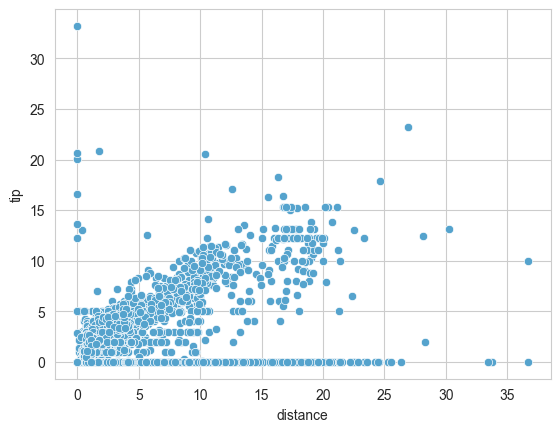

In [3]:
# Также рассмотрим взаимосвязь переменных tip (чаевые) и distance (дистан-ция) (коэффициент корреляции составляет 0,45 - средняя корреляция)
sns.scatterplot(df, x="distance", y="tip")
# По графику видно, что наблюдения располагаются более разрозненно, также присутсвует много нулевых значений

# Например, рассмотрим медианное значение чаевых, оставляемых в такси раз-ного цвета
# Для этого в параметр by функции groupby передаем столбец color, по кото-рому будет происходить разделение на группы (желтые, зеленые)
# .median() задает агреггирующую функцию
df[['color','tip']].groupby(by= 'color').median()

# Также в groupby можно передавать несколько столбцов
# Посмотрим, какая средняя стоимость поездки в топ-10 зонах и районах
# Функция sort_values сортирует значения, а параметр ascending задает направление сортировки
df[['pickup_borough','pickup_zone','total']].groupby(by=['pickup_borough','pickup_zone']).mean().sort_values(by='total', ascending=False).head(10)

In [4]:
df['time'] = df['dropoff'] - df['pickup'] # Расчет времени поездки
df['time'] = df['time'].dt.total_seconds()/60 # Перевод в минуты при помо-щи модуля dt и функции .total_seconds()
df['speed'] = df['distance']/df['time'] # Рассчитываем среднюю скорость как дистанция/время
df['speed'] = df['speed'].fillna(df['speed'].median()) # Заполняем пропу-щенные значения для работы статистических алгоритмов

df[['speed', 'color']].groupby(by='color').mean() # Посмотрим на значение средней скорости в группах
# Видим различие в 0,02 км/мин, по нему мы точно не можем сказать различа-ются ли группы в статистическом плане

# Разделим данные на группы
group_yellow = df['speed'][df['color'] == 'yellow']
group_green = df['speed'][df['color'] == 'green']

from scipy.stats import f_oneway # Импорт функции для дисперсионного ана-лиза (в даном примере используем однофакторный)
f_stat, p_value = f_oneway(group_yellow, group_green) # функция возвращает два значения: значение критерия Фишера и p-значение  
print(f"F-statistic: {f_stat}, P-value: {p_value}") # Вывод результата

# Проверим гипотезу при помощи критерия хи-квадрат 
df['speed_category'] = '' # Создаем категоризированную переменную для ско-рости
df.loc[df['speed']<= df['speed'].median(),'speed_category'] = 'Низкая' # Проводим разделение по медиане на низкую и высокую скорость
df.loc[df['speed']> df['speed'].median(),'speed_category']  = 'Высокая'

# Для проведения теста необходимо создать таблицу сопряженности
# Таблица сопряженности показывает частоты совместного появления категорий
pd.crosstab(df['speed_category'], df['color'])

from scipy.stats import chi2_contingency # Импорт функции для хи-квадрат
chi2, p, dof, expected = chi2_contingency(pd.crosstab(df['speed_category'], df['color'])) # Функция принимает таблицу сопряженности
# и возвращает статистику хи-квадрат, p-значение, степени свободы (dof) и ожидаемые частоты
# число степеней свободы — это количество значений, используемых при рас-чете статистической характеристики, которые могут свободно изменяться
print(f"χ²: {chi2}, P-value: {p}")

F-statistic: 0.26660045643847763, P-value: 0.6056391384084638
χ²: 34.759572607836894, P-value: 3.730399329812916e-09


# Задание 1
## 1. Скачать данные по ссылке https://www.kaggle.com/datasets/yasserh/titanic-dataset;
## 2. При помощи критерия хи-квадрат проверить гипотезу о независимости пола и выживания;
## 3. Создать категориальную переменную ребенок/взрослый, проверить гипотезу о независимости возраста и выживания. 

In [12]:
# Импорт библиотек
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency
import warnings
warnings.filterwarnings('ignore')

# ============================================
# 1. ЗАГРУЗКА И ПОДГОТОВКА ДАННЫХ
# ============================================

# Загружаем данные
df = pd.read_csv('Titanic-Dataset.csv')

print(f"\nРазмер датасета: {df.shape}")
print(f"Колонки: {df.columns.tolist()}")

# Проверяем пропущенные значения
print("\nПропущенные значения:")
print(df.isnull().sum())

# Удаляем строки с пропущенными значениями в ключевых колонках
df_clean = df.dropna(subset=['Sex', 'Age', 'Survived']).copy()
print(f"\nРазмер после удаления пропусков: {df_clean.shape}")

# Проверяем, что Survived - категориальная переменная (0 или 1)
print(f"\nУникальные значения Survived: {df_clean['Survived'].unique()}")
print(f"Уникальные значения Sex: {df_clean['Sex'].unique()}")

# ============================================
# 2. ГИПОТЕЗА 1: НЕЗАВИСИМОСТЬ ПОЛА И ВЫЖИВАНИЯ
# ============================================

print("\n" + "="*60)
print("ГИПОТЕЗА 1: Независимость пола и выживания")
print("="*60)

# Формулируем гипотезы
print("\nН0: Пол и выживание независимы")
print("Н1: Пол и выживание зависимы (существует связь)")

# Создаем таблицу сопряженности
contingency_table_sex = pd.crosstab(df_clean['Sex'], df_clean['Survived'], 
                                     rownames=['Пол'], colnames=['Выживание'])
print("\nТаблица сопряженности (Пол x Выживание):")
print(contingency_table_sex)
print("\n(0 = Погиб, 1 = Выжил)")

# Рассчитываем проценты для наглядности
print("\nПроцент выживших по полу:")
sex_survival_pct = df_clean.groupby('Sex')['Survived'].mean() * 100
for sex, pct in sex_survival_pct.items():
    print(f"  {sex}: {pct:.1f}%")

# Применяем критерий хи-квадрат
chi2, p_value, dof, expected = chi2_contingency(contingency_table_sex)

print(f"\nРезультаты теста хи-квадрат:")
print(f"  χ² (хи-квадрат): {chi2:.4f}")
print(f"  p-value: {p_value:.10f}")
print(f"  degrees of freedom (степени свободы): {dof}")

print("\nОжидаемые частоты (если бы гипотеза Н0 была верна):")
expected_df = pd.DataFrame(expected, 
                          index=contingency_table_sex.index,
                          columns=contingency_table_sex.columns)
print(expected_df)

# Интерпретация результата
alpha = 0.05
print(f"\nИНТЕРПРЕТАЦИЯ (уровень значимости α = {alpha}):")

if p_value < alpha:
    print("  p-value < α → Отвергаем нулевую гипотезу H0")
    print("  Существует статистически значимая зависимость между полом и выживанием")
    print("  Вывод: Пол влиял на вероятность выживания на Титанике")
else:
    print("  p-value ≥ α → Нет оснований отвергнуть H0")
    print("  Нет статистически значимой зависимости между полом и выживанием")

# ============================================
# 3. ГИПОТЕЗА 2: НЕЗАВИСИМОСТЬ ВОЗРАСТА И ВЫЖИВАНИЯ
# ============================================

print("\n" + "="*60)
print("ГИПОТЕЗА 2: Независимость возраста (ребенок/взрослый) и выживания")
print("="*60)

# Создаем категориальную переменную "ребенок/взрослый"
# В начале 20 века ребенком считали до 12-14 лет. Возьмем 12 лет как границу.
age_threshold = 12
df_clean['Age_Category'] = np.where(df_clean['Age'] <= age_threshold, 'Ребенок', 'Взрослый')

print(f"\nВозрастная граница: {age_threshold} лет")
print("\nРаспределение по возрастным категориям:")
print(df_clean['Age_Category'].value_counts())

# Формулируем гипотезы
print("\nН0: Возрастная категория и выживание независимы")
print("Н1: Возрастная категория и выживание зависимы")

# Создаем таблицу сопряженности
contingency_table_age = pd.crosstab(df_clean['Age_Category'], df_clean['Survived'],
                                     rownames=['Возрастная группа'], colnames=['Выживание'])
print("\nТаблица сопряженности (Возраст x Выживание):")
print(contingency_table_age)

# Рассчитываем проценты
print("\nПроцент выживших по возрастным группам:")
age_survival_pct = df_clean.groupby('Age_Category')['Survived'].mean() * 100
for cat, pct in age_survival_pct.items():
    print(f"  {cat}: {pct:.1f}%")

# Применяем критерий хи-квадрат
chi2_age, p_value_age, dof_age, expected_age = chi2_contingency(contingency_table_age)

print(f"\nРезультаты теста хи-квадрат:")
print(f"  χ² (хи-квадрат): {chi2_age:.4f}")
print(f"  p-value: {p_value_age:.6f}")
print(f"  degrees of freedom: {dof_age}")

print("\nОжидаемые частоты (если бы гипотеза Н0 была верна):")
expected_age_df = pd.DataFrame(expected_age,
                               index=contingency_table_age.index,
                               columns=contingency_table_age.columns)
print(expected_age_df)

# Интерпретация результата
print(f"\nИНТЕРПРЕТАЦИЯ (уровень значимости α = {alpha}):")

if p_value_age < alpha:
    print("  p-value < α → Отвергаем нулевую гипотезу H0")
    print("  Существует статистически значимая зависимость между возрастом и выживанием")
    print("  Вывод: Дети имели другие шансы на выживание по сравнению со взрослыми")
else:
    print("  p-value ≥ α → Нет оснований отвергнуть H0")
    print("  Нет статистически значимой зависимости между возрастом и выживанием")

# ============================================
# 4. ДОПОЛНИТЕЛЬНЫЙ АНАЛИЗ
# ============================================

print("\n" + "="*60)
print("ДОПОЛНИТЕЛЬНЫЙ АНАЛИЗ: ДЕТАЛИЗАЦИЯ ПО ВОЗРАСТУ")
print("="*60)

# Проверим разные возрастные границы
print("\nПроверка чувствительности к выбору границы 'ребенок':")
for threshold in [10, 12, 14, 16, 18]:
    df_clean[f'Age_Cat_{threshold}'] = np.where(df_clean['Age'] <= threshold, f'≤{threshold}', f'>{threshold}')
    ct = pd.crosstab(df_clean[f'Age_Cat_{threshold}'], df_clean['Survived'])
    chi2, p, _, _ = chi2_contingency(ct)
    surv_pct = df_clean.groupby(f'Age_Cat_{threshold}')['Survived'].mean() * 100
    print(f"\nГраница {threshold} лет:")
    print(f"  Выживаемость: дети {surv_pct.get(f'≤{threshold}', 0):.1f}%, взрослые {surv_pct.get(f'>{threshold}', 0):.1f}%")
    print(f"  p-value = {p:.6f} - {'Зависимость есть' if p < 0.05 else 'Независимы'}")


Размер датасета: (891, 12)
Колонки: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

Пропущенные значения:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Размер после удаления пропусков: (714, 12)

Уникальные значения Survived: [0 1]
Уникальные значения Sex: <StringArray>
['male', 'female']
Length: 2, dtype: str

ГИПОТЕЗА 1: Независимость пола и выживания

Н0: Пол и выживание независимы
Н1: Пол и выживание зависимы (существует связь)

Таблица сопряженности (Пол x Выживание):
Выживание    0    1
Пол                
female      64  197
male       360   93

(0 = Погиб, 1 = Выжил)

Процент выживших по полу:
  female: 75.5%
  male: 20.5%

Результаты теста хи-квадрат:
  χ² (хи-квадрат): 205.0258
  p-value: 0.0000000000
  degrees of

# Задание (4 балла)
## 1. Скачать данные по ссылке https://www.kaggle.com/datasets/rufmus/simulated-ab-test-data/data?select=sessions_data.csv;
## 2. Проверить следующие гипотезы:
- нет различий между количеством бронирований у групп пользователей из файла users_data.csv;
- нет различий между средним временем до бронирования с начала сессии у групп пользователей из файла users_data.csv;
- нет различий между количеством бронирований, совершаемых в разные промежутки времени (день/ночь). 

In [17]:
# Импорт библиотек
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency, ttest_ind, mannwhitneyu
import warnings
warnings.filterwarnings('ignore')

# Настройка отображения
pd.set_option('display.max_rows', 20)
pd.set_option('display.max_columns', None)

# ============================================
# 1. ЗАГРУЗКА ДАННЫХ
# ============================================

print("="*60)
print("ЗАДАНИЕ *: A/B ТЕСТИРОВАНИЕ")
print("="*60)

users_df = pd.read_csv('users_data.csv')
sessions_df = pd.read_csv('sessions_data.csv')
print("Файлы успешно загружены")

print("\n" + "="*60)
print("1. ПРЕДВАРИТЕЛЬНЫЙ ПРОСМОТР ДАННЫХ")
print("="*60)

print("\nusers_data.csv:")
print(users_df.head())
print(f"Размер: {users_df.shape}")
print(f"Колонки: {users_df.columns.tolist()}")

print("\nsessions_data.csv:")
print(sessions_df.head())
print(f"Размер: {sessions_df.shape}")
print(f"Колонки: {sessions_df.columns.tolist()}")

# ============================================
# 2. ПОДГОТОВКА ДАННЫХ
# ============================================

print("\n" + "="*60)
print("2. ПОДГОТОВКА ДАННЫХ")
print("="*60)

# Объединяем данные
merged_df = pd.merge(sessions_df, users_df, on='user_id', how='inner')
print(f"Размер объединенных данных: {merged_df.shape}")

# Создаем колонку с индикатором бронирования
# Бронирование есть, если booking_timestamp не пустой
merged_df['is_booked'] = merged_df['booking_timestamp'].notna().astype(int)
print(f"Количество бронирований: {merged_df['is_booked'].sum()}")

# ============================================
# 3. ГИПОТЕЗА 1: КОЛИЧЕСТВО БРОНИРОВАНИЙ ПО ГРУППАМ
# ============================================

print("\n" + "="*60)
print("ГИПОТЕЗА 1: Количество бронирований у групп control и variant")
print("="*60)

print("Н0: Нет различий в количестве бронирований между группами")
print("Н1: Различия в количестве бронирований между группами существуют")

# Агрегируем бронирования по пользователям
user_bookings = merged_df.groupby(['user_id', 'experiment_group'])['is_booked'].sum().reset_index()
print(f"\nДанные по бронированиям пользователей: {user_bookings.shape}")

# Распределение по группам
group_counts = user_bookings['experiment_group'].value_counts()
print("\nРаспределение пользователей по группам:")
print(group_counts)

# Статистика по группам
group_stats = user_bookings.groupby('experiment_group')['is_booked'].agg(['mean', 'median', 'std', 'count'])
print("\nСтатистика бронирований по группам:")
print(group_stats.round(2))

# Критерий Манна-Уитни
group_control = user_bookings[user_bookings['experiment_group'] == 'control']['is_booked']
group_variant = user_bookings[user_bookings['experiment_group'] == 'variant']['is_booked']

u_stat, p_value_books = mannwhitneyu(group_control, group_variant, alternative='two-sided')

print(f"\nРезультаты теста Манна-Уитни:")
print(f"U-статистика: {u_stat:.2f}")
print(f"p-value: {p_value_books:.6f}")

# Интерпретация
alpha = 0.05
print(f"\nИНТЕРПРЕТАЦИЯ (α = {alpha}):")

if p_value_books < alpha:
    print("p-value < α → Отвергаем H0")
    print("Статистически значимые различия между группами")
    if group_control.mean() > group_variant.mean():
        print(f"Группа control бронирует больше (среднее: {group_control.mean():.2f} vs {group_variant.mean():.2f})")
    else:
        print(f"Группа variant бронирует больше (среднее: {group_variant.mean():.2f} vs {group_control.mean():.2f})")
else:
    print("p-value ≥ α → Нет оснований отвергнуть H0")
    print("Нет статистически значимых различий между группами")

# ============================================
# 4. ГИПОТЕЗА 2: ВРЕМЯ ДО БРОНИРОВАНИЯ
# ============================================

print("\n" + "="*60)
print("ГИПОТЕЗА 2: Среднее время до бронирования")
print("="*60)

print("Н0: Нет различий во времени до бронирования между группами")
print("Н1: Различия во времени до бронирования между группами существуют")

# Берем только успешные бронирования с ненулевым временем
successful_bookings = merged_df[merged_df['is_booked'] == 1].copy()
successful_bookings = successful_bookings[successful_bookings['time_to_booking'].notna()]
print(f"\nКоличество успешных бронирований с временем: {len(successful_bookings)}")

if len(successful_bookings) > 0:
    time_stats = successful_bookings.groupby('experiment_group')['time_to_booking'].agg(['mean', 'median', 'std', 'count'])
    print("\nСтатистика времени до бронирования (в минутах):")
    print(time_stats.round(2))

    time_control = successful_bookings[successful_bookings['experiment_group'] == 'control']['time_to_booking']
    time_variant = successful_bookings[successful_bookings['experiment_group'] == 'variant']['time_to_booking']
    
    # Проверяем, что в обеих группах есть данные
    if len(time_control) > 0 and len(time_variant) > 0:
        t_stat, p_value_time = ttest_ind(time_control, time_variant, equal_var=False, nan_policy='omit')
        print(f"\nРезультаты t-теста Уэлча:")
        print(f"t-статистика: {t_stat:.4f}")
        print(f"p-value: {p_value_time:.6f}")

        if p_value_time < alpha:
            print("p-value < α → Отвергаем H0")
            print("Статистически значимые различия во времени")
            if time_control.mean() < time_variant.mean():
                print(f"Группа control быстрее (среднее: {time_control.mean():.1f} мин vs {time_variant.mean():.1f} мин)")
            else:
                print(f"Группа variant быстрее (среднее: {time_variant.mean():.1f} мин vs {time_control.mean():.1f} мин)")
        else:
            print("p-value ≥ α → Нет оснований отвергнуть H0")
            print("Нет статистически значимых различий во времени")
    else:
        print("В одной из групп нет данных о времени бронирования")
else:
    print("Нет успешных бронирований для анализа времени")

# ============================================
# 5. ГИПОТЕЗА 3: БРОНИРОВАНИЯ ДНЕМ И НОЧЬЮ
# ============================================

print("\n" + "="*60)
print("ГИПОТЕЗА 3: Бронирования днем и ночью")
print("="*60)

print("Н0: Количество бронирований не зависит от времени суток")
print("Н1: Количество бронирований зависит от времени суток")

# Используем session_start_timestamp для определения времени суток
merged_df['session_start_timestamp'] = pd.to_datetime(merged_df['session_start_timestamp'])
merged_df['hour'] = merged_df['session_start_timestamp'].dt.hour
merged_df['is_night'] = ((merged_df['hour'] >= 22) | (merged_df['hour'] <= 5)).astype(int)

print(f"\nРаспределение сессий по времени суток:")
print(merged_df['is_night'].value_counts().rename({0: 'День', 1: 'Ночь'}))

# Таблица сопряженности
contingency = pd.crosstab(
    merged_df['is_booked'], 
    merged_df['is_night'],
    rownames=['Бронирование'],
    colnames=['Время суток']
)
contingency.columns = ['День', 'Ночь']
contingency.index = ['Не забронировано', 'Забронировано']

print("\nТаблица сопряженности:")
print(contingency)

# Проценты бронирований
day_rate = merged_df[merged_df['is_night'] == 0]['is_booked'].mean() * 100
night_rate = merged_df[merged_df['is_night'] == 1]['is_booked'].mean() * 100
print(f"\nПроцент бронирований:")
print(f"  День: {day_rate:.2f}%")
print(f"  Ночь: {night_rate:.2f}%")

# Хи-квадрат
chi2, p_value_dn, dof, expected = chi2_contingency(contingency)

print(f"\nРезультаты теста хи-квадрат:")
print(f"χ² = {chi2:.4f}, p-value = {p_value_dn:.6f}")

if p_value_dn < alpha:
    print("p-value < α → Отвергаем H0")
    print("Зависимость между временем суток и бронированиями существует")
    if night_rate > day_rate:
        print("Ночью бронируют чаще")
    else:
        print("Днем бронируют чаще")
else:
    print("p-value ≥ α → Нет оснований отвергнуть H0")
    print("Нет зависимости между временем суток и бронированиями")

ЗАДАНИЕ *: A/B ТЕСТИРОВАНИЕ
Файлы успешно загружены

1. ПРЕДВАРИТЕЛЬНЫЙ ПРОСМОТР ДАННЫХ

users_data.csv:
            user_id experiment_group
0  MZCoQh8uM5swkkx0          control
1  JNxcv0bxRDLb7uGl          control
2  5v8RyWA6PB7po99U          variant
3  9YR2Z4cKYguiMrdy          control
4  7nX5iz0btBU7gR8h          control
Размер: (10000, 2)
Колонки: ['user_id', 'experiment_group']

sessions_data.csv:
         session_id           user_id        session_start_timestamp booking_timestamp  time_to_booking
0  E5BlPLR02J9sDhEG  MZCoQh8uM5swkkx0  2025-01-15 04:25:54.958087206               NaN              NaN
1  iLMbzHEvm30rA7hL  JNxcv0bxRDLb7uGl  2025-01-15 01:30:53.094253063               NaN              NaN
2  1TPSZa4I3ngbgge6  5v8RyWA6PB7po99U  2025-01-30 20:38:12.784697294               NaN              NaN
3  YZUNhw1Es5By4GLE  9YR2Z4cKYguiMrdy  2025-01-13 22:24:08.170474529               NaN              NaN
4  Drl43dyy9WnaoJnM  7nX5iz0btBU7gR8h  2025-01-16 18:09:52.509284258     